In [2]:
import numpy as np
import cv2
import mediapipe as mp

print("numpy:", np.__version__)
print("cv2:", cv2.__version__)
print("mediapipe:", mp.__version__)
print("solutions exists:", hasattr(mp, "solutions"))



numpy: 1.26.4
cv2: 4.13.0
mediapipe: 0.10.9
solutions exists: True


In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

# =========================
# Paths & config
# =========================
DATA_ROOT = Path(r"D:\dowsiness\eye")

IMG = 128
BATCH = 128
SEED = 42
CLASS_NAMES = ["closed", "opened"]
AUTOTUNE = tf.data.AUTOTUNE

# =========================
# Check if data exists
# =========================
print("Checking data directories...")
for split in ["train", "valid", "test"]:
    split_path = DATA_ROOT / split
    if not split_path.exists():
        print(f"ERROR: {split_path} does not exist!")
        print(f"Please ensure your data is organized as:")
        print(f"  D:\\dowsiness\\eye\\train\\closed\\")
        print(f"  D:\\dowsiness\\eye\\train\\opened\\")
        print(f"  D:\\dowsiness\\eye\\valid\\closed\\")
        print(f"  D:\\dowsiness\\eye\\valid\\opened\\")
        print(f"  D:\\dowsiness\\eye\\test\\closed\\")
        print(f"  D:\\dowsiness\\eye\\test\\opened\\")
    else:
        print(f"✓ {split_path} exists")

# =========================
# Dataset loaders
# =========================
def make_ds(split: str, shuffle: bool):
    ds = tf.keras.utils.image_dataset_from_directory(
        DATA_ROOT / split,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        image_size=(IMG, IMG),
        batch_size=BATCH,
        shuffle=shuffle,
        seed=SEED
    )
    ds = ds.cache()
    ds = ds.prefetch(AUTOTUNE)
    return ds

print("\nLoading datasets...")
train_ds = make_ds("train", shuffle=True)
val_ds   = make_ds("valid", shuffle=False)
test_ds  = make_ds("test",  shuffle=False)
print("✓ Datasets loaded successfully!")

# =========================
# Model architecture
# =========================
aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.25),
], name="augmentation")

noise = layers.GaussianNoise(0.02)

base = tf.keras.applications.MobileNetV3Small(
    input_shape=(IMG, IMG, 3),
    include_top=False,
    weights="imagenet"
)

inp = keras.Input(shape=(IMG, IMG, 3))
x = aug(inp)
x = noise(x)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

base.trainable = False
x = base(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.20)(x)
out = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inp, out)

# =========================
# Training setup
# =========================
CKPT_PATH = "eyes_best.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        CKPT_PATH,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

def compile_model(lr: float):
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.02),
        metrics=[
            keras.metrics.BinaryAccuracy(name="acc", threshold=0.5),
            keras.metrics.AUC(name="auc")
        ]
    )

# Load best weights if exist
if os.path.exists(CKPT_PATH):
    print(f"\n[Resume] Loading weights from {CKPT_PATH}")
    model.load_weights(CKPT_PATH)

# =========================
# Stage 1: Train head
# =========================
print("\n== Stage 1: Train head (backbone frozen) ==")
compile_model(lr=1e-3)
history_stage1 = model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=callbacks)

# =========================
# Stage 2: Fine-tune
# =========================
print("\n== Stage 2: Fine-tune (unfreeze last layers) ==")
base.trainable = True
for layer in base.layers[:-45]:
    layer.trainable = False

compile_model(lr=8e-5)
history_stage2 = model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=callbacks)

# =========================
# Test evaluation
# =========================
print("\n== Test evaluation ==")
model.load_weights(CKPT_PATH)
metrics = model.evaluate(test_ds, verbose=2)
print("Test metrics:", dict(zip(model.metrics_names, metrics)))

# =========================
# Save model
# =========================
MODEL_OUTPUT = "eyes_mnv3_openprob.keras"
print(f"\nSaving model as {MODEL_OUTPUT}...")
try:
    model.save(MODEL_OUTPUT)
    print(f"✓ Successfully saved: {MODEL_OUTPUT}")
except Exception as e:
    print(f"ERROR saving model: {e}")
    print("The model may not be available for threshold finding or TFLite conversion.")


Found 54784 files belonging to 2 classes.
Found 17353 files belonging to 2 classes.
Found 17116 files belonging to 2 classes.


4334752/4334752 [==============================] - 2s 0us/step

== Stage 1: Train head (backbone frozen) ==
Epoch 1/35

428/428 [==============================] - ETA: 0s - loss: 0.3612 - acc: 0.8619 - auc: 0.9351
Epoch 1: val_auc improved from -inf to 0.97657, saving model to eyes_best.weights.h5
428/428 [==============================] - 86s 193ms/step - loss: 0.3612 - acc: 0.8619 - auc: 0.9351 - val_loss: 0.2537 - val_acc: 0.9177 - val_auc: 0.9766 - lr: 0.0010
Epoch 2/35
428/428 [==============================] - ETA: 0s - loss: 0.2648 - acc: 0.9103 - auc: 0.9677
Epoch 2: val_auc improved from 0.97657 to 0.98349, saving model to eyes_best.weights.h5
428/428 [==============================] - 84s 197ms/step - loss: 0.2648 - acc: 0.9103 - auc: 0.9677 - val_loss: 0.2197 - val_acc: 0.9306 - val_auc: 0.9835 - lr: 0.0010
Epoch 3/35
428/428 [=====================

In [12]:
print("\n== Stage 1: Train head (backbone frozen) ==")
compile_model(lr=1e-3)
history_stage1 = model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=callbacks)


== Stage 1: Train head (backbone frozen) ==
Epoch 1/2
428/428 [==============================] - ETA: 0s - loss: 0.2977 - acc: 0.8957 - auc: 0.9573
Epoch 1: val_auc improved from -inf to 0.98005, saving model to eyes_best.weights.h5
428/428 [==============================] - 129s 296ms/step - loss: 0.2977 - acc: 0.8957 - auc: 0.9573 - val_loss: 0.2342 - val_acc: 0.9239 - val_auc: 0.9800 - lr: 0.0010
Epoch 2/2
428/428 [==============================] - ETA: 0s - loss: 0.2545 - acc: 0.9157 - auc: 0.9701
Epoch 2: val_auc improved from 0.98005 to 0.98468, saving model to eyes_best.weights.h5
428/428 [==============================] - 128s 299ms/step - loss: 0.2545 - acc: 0.9157 - auc: 0.9701 - val_loss: 0.2136 - val_acc: 0.9339 - val_auc: 0.9847 - lr: 0.0010


In [13]:
print("\n== Stage 2: Fine-tune (unfreeze last layers) ==")
base.trainable = True
for layer in base.layers[:-45]:
    layer.trainable = False

compile_model(lr=8e-5)
history_stage2 = model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=callbacks)


== Stage 2: Fine-tune (unfreeze last layers) ==
Epoch 1/2
428/428 [==============================] - ETA: 0s - loss: 0.1598 - acc: 0.9553 - auc: 0.9917
Epoch 1: val_auc improved from 0.98468 to 0.99788, saving model to eyes_best.weights.h5
428/428 [==============================] - 149s 341ms/step - loss: 0.1598 - acc: 0.9553 - auc: 0.9917 - val_loss: 0.1103 - val_acc: 0.9784 - val_auc: 0.9979 - lr: 8.0000e-05
Epoch 2/2
428/428 [==============================] - ETA: 0s - loss: 0.1271 - acc: 0.9693 - auc: 0.9960
Epoch 2: val_auc improved from 0.99788 to 0.99841, saving model to eyes_best.weights.h5
428/428 [==============================] - 151s 353ms/step - loss: 0.1271 - acc: 0.9693 - auc: 0.9960 - val_loss: 0.1029 - val_acc: 0.9810 - val_auc: 0.9984 - lr: 8.0000e-05


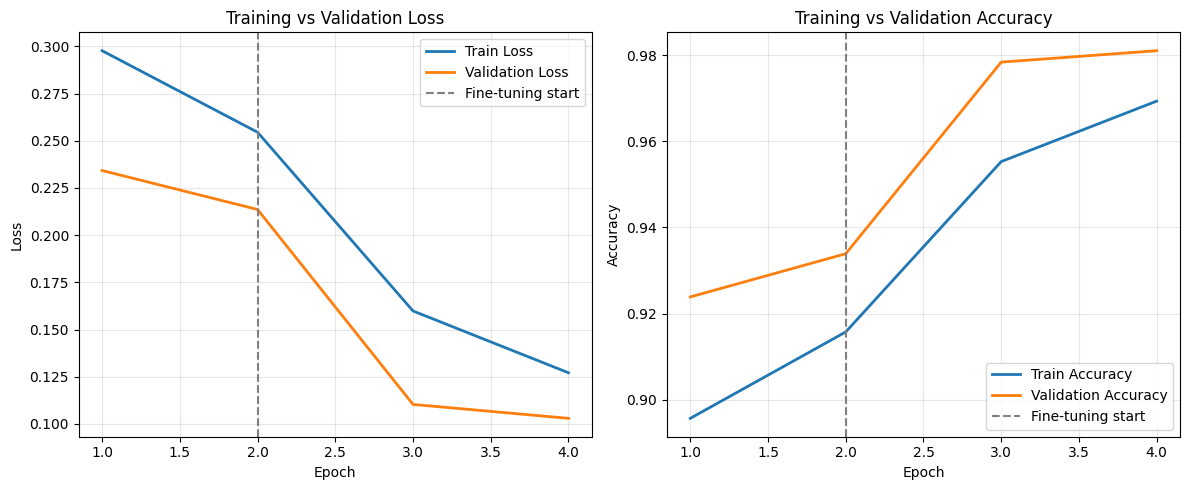

In [14]:
import matplotlib.pyplot as plt

all_loss = history_stage1.history['loss'] + history_stage2.history['loss']
all_val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

all_acc = history_stage1.history['acc'] + history_stage2.history['acc']
all_val_acc = history_stage1.history['val_acc'] + history_stage2.history['val_acc']

epochs = range(1, len(all_loss) + 1)
stage_boundary = len(history_stage1.history['loss'])

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, all_loss, linewidth=2, label="Train Loss")
plt.plot(epochs, all_val_loss, linewidth=2, label="Validation Loss")
plt.axvline(stage_boundary, linestyle="--", color="gray", label="Fine-tuning start")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, all_acc, linewidth=2, label="Train Accuracy")
plt.plot(epochs, all_val_acc, linewidth=2, label="Validation Accuracy")
plt.axvline(stage_boundary, linestyle="--", color="gray", label="Fine-tuning start")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

3/3 [==============================] - 1s 60ms/step


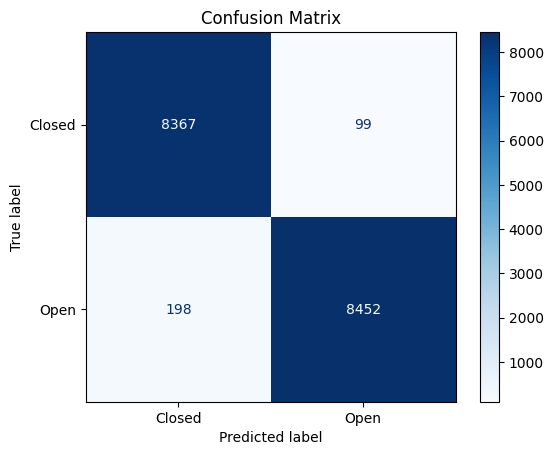

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Closed","Open"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

3/3 [==============================] - 0s 56ms/step


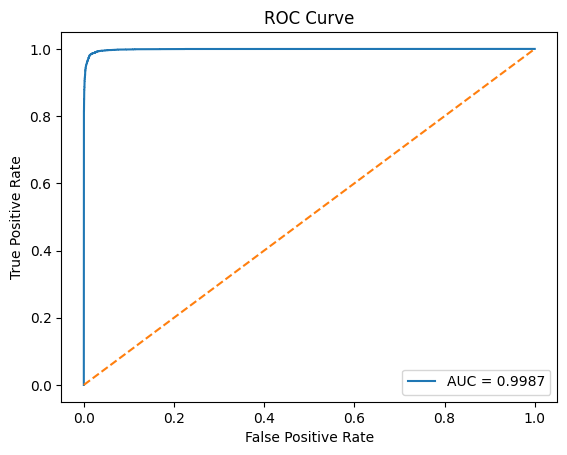

In [16]:
from sklearn.metrics import roc_curve, auc

y_true = []
y_score = []

for images, labels in test_ds:
    preds = model.predict(images)

    y_true.extend(labels.numpy().flatten())
    y_score.extend(preds.flatten())

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
from pathlib import Path
from PIL import Image
import random
import os

DATA_ROOT = Path(r"D:\dowsiness\eye")
IMG = 128
MODEL_PATH = "eyes_mnv3_openprob.keras"

# Check if model exists
if not os.path.exists(MODEL_PATH):
    print(f"ERROR: {MODEL_PATH} not found!")
    print("SOLUTION: Run cell 4 (training) first to create the model.")
else:
    try:
        print(f"Loading model from {MODEL_PATH}...")
        model = tf.keras.models.load_model(MODEL_PATH)
        print("✓ Model loaded successfully!")
        
        # Create representative dataset for quantization
        def rep_gen():
            exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
            all_imgs = []
            for cls in ["closed", "opened"]:
                d = DATA_ROOT / "train" / cls
                if d.exists():
                    all_imgs += [p for p in d.iterdir() if p.suffix.lower() in exts]
            
            if not all_imgs:
                print("WARNING: No training images found for quantization!")
                return
            
            random.shuffle(all_imgs)
            print(f"Using {min(400, len(all_imgs))} images for quantization...")
            for p in all_imgs[:400]:
                try:
                    img = Image.open(p).convert("RGB").resize((IMG, IMG))
                    x = np.array(img, dtype=np.float32)[None, ...]
                    yield [x]
                except Exception as e:
                    print(f"Skipping {p}: {e}")

        print("\nConverting to INT8 TFLite...")
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = rep_gen

        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

        tflite_model = converter.convert()
        Path("eyes_int8.tflite").write_bytes(tflite_model)

        print("✓ Saved: eyes_int8.tflite")
        print(f"  File size: {len(tflite_model) / 1024 / 1024:.2f} MB")
        
    except Exception as e:
        print(f"ERROR: {e}")
        print("SOLUTION: Make sure cell 4 (training) completed successfully.")

INFO:tensorflow:Assets written to: C:\Users\rwank\AppData\Local\Temp\tmp8_yk1wyf\assets


INFO:tensorflow:Assets written to: C:\Users\rwank\AppData\Local\Temp\tmp8_yk1wyf\assets
C:\Users\rwank\anaconda3\envs\drowsy\lib\site-packages\tensorflow\lite\python\convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


 Saved: eyes_int8.tflite


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

DATA_ROOT = Path(r"D:\dowsiness\eye")
IMG = 128
BATCH = 128
CLASS_NAMES = ["closed", "opened"]

MODEL_PATH = "eyes_mnv3_openprob.keras"

# Check if model exists
if not os.path.exists(MODEL_PATH):
    print(f"ERROR: Model file not found at {MODEL_PATH}")
    print("Please run the training cell (cell 4) first to create the model.")
else:
    try:
        print(f"Loading model from {MODEL_PATH}...")
        model = keras.models.load_model(MODEL_PATH)
        print("✓ Model loaded successfully!")
        
        val_ds = tf.keras.utils.image_dataset_from_directory(
            DATA_ROOT / "valid",
            labels="inferred",
            label_mode="binary",
            class_names=CLASS_NAMES,
            image_size=(IMG, IMG),
            batch_size=BATCH,
            shuffle=False
        ).prefetch(tf.data.AUTOTUNE)

        print("Computing predictions...")
        y_true, y_prob = [], []
        for x, y in val_ds:
            p = model.predict(x, verbose=0).reshape(-1)
            y_prob.append(p)
            y_true.append(y.numpy().reshape(-1))

        y_true = np.concatenate(y_true)
        y_prob = np.concatenate(y_prob)

        # Find best threshold
        best_t, best_acc = 0.5, 0.0
        thresholds = np.linspace(0.1, 0.9, 81)
        accuracies = []
        for t in thresholds:
            acc = ((y_prob >= t).astype(np.float32) == y_true).mean()
            accuracies.append(acc)
            if acc > best_acc:
                best_acc, best_t = acc, t

        print(f"\n=== Threshold Analysis ===")
        print(f"Best threshold: {best_t:.4f}")
        print(f"Best accuracy: {best_acc:.4f}")
        
        # Create performance plots
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # 1. Accuracy vs Threshold
        axes[0, 0].plot(thresholds, accuracies, 'b-', linewidth=2, marker='o', markersize=4)
        axes[0, 0].axvline(best_t, color='r', linestyle='--', linewidth=2, label=f'Best: {best_t:.3f}')
        axes[0, 0].scatter([best_t], [best_acc], color='r', s=100, zorder=5)
        axes[0, 0].set_xlabel('Threshold', fontsize=10)
        axes[0, 0].set_ylabel('Accuracy', fontsize=10)
        axes[0, 0].set_title('Accuracy vs Threshold', fontsize=11, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
        axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        axes[0, 1].set_xlabel('False Positive Rate', fontsize=10)
        axes[0, 1].set_ylabel('True Positive Rate', fontsize=10)
        axes[0, 1].set_title('ROC Curve', fontsize=11, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Prediction Distribution
        axes[1, 0].hist(y_prob[y_true==0], bins=30, alpha=0.6, label='Closed (y=0)', color='red', edgecolor='black')
        axes[1, 0].hist(y_prob[y_true==1], bins=30, alpha=0.6, label='Opened (y=1)', color='blue', edgecolor='black')
        axes[1, 0].axvline(best_t, color='g', linestyle='--', linewidth=2, label=f'Best threshold: {best_t:.3f}')
        axes[1, 0].set_xlabel('Predicted Probability', fontsize=10)
        axes[1, 0].set_ylabel('Frequency', fontsize=10)
        axes[1, 0].set_title('Prediction Distribution', fontsize=11, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        
        # 4. Confusion Matrix
        y_pred = (y_prob >= best_t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        cm_display = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
        cm_display.plot(ax=axes[1, 1], cmap='Blues', values_format='d')
        axes[1, 1].set_title('Confusion Matrix', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print metrics
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        print(f"\n=== Detailed Metrics ===")
        print(f"True Negatives: {tn}, False Positives: {fp}")
        print(f"False Negatives: {fn}, True Positives: {tp}")
        print(f"Sensitivity (Recall): {sensitivity:.4f}")
        print(f"Specificity: {specificity:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        
    except Exception as e:
        print(f"ERROR loading model: {e}")
        print("The model file may be corrupted or incompatible.")
        print("Solution: Run the training cell (cell 4) to retrain the model.")

Found 17353 files belonging to 2 classes.
Best threshold: 0.39
Best val accuracy: 0.9869763153345242


In [ ]:
###avg cloooooose

In [2]:
import cv2
import numpy as np
from collections import deque
import mediapipe as mp
import tensorflow as tf

# =========================
# Config
# =========================
MODEL_PATH = r"C:\Users\rwank\OneDrive\Desktop\SAV\model\eyes_int8.tflite"
IMG = 128

# Equivalent close thresholds of your open thresholds:
# open >= 0.45  <=> close <= 0.55
# open <= 0.33  <=> close >= 0.67
CLOSE_ON  = 0.67   # switch to CLOSED if avg_close >= this
CLOSE_OFF = 0.55   # switch back to OPEN if avg_close <= this

SMOOTH_N = 11
MARGIN = 0.25
CAM_W, CAM_H = 640, 480

# =========================
# Load TFLite INT8 model
# =========================
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

in_scale, in_zero = inp["quantization"]
out_scale, out_zero = out["quantization"]

def predict_open_prob(eye_bgr: np.ndarray) -> float:
    eye_rgb = cv2.cvtColor(eye_bgr, cv2.COLOR_BGR2RGB)
    eye_rgb = cv2.resize(eye_rgb, (IMG, IMG), interpolation=cv2.INTER_AREA)
    x = eye_rgb.astype(np.float32)

    xq = (x / in_scale + in_zero).astype(np.int8)[None, ...]
    interpreter.set_tensor(inp["index"], xq)
    interpreter.invoke()

    yq = interpreter.get_tensor(out["index"])[0][0]
    y = (yq - out_zero) * out_scale
    return float(y)

# =========================
# MediaPipe FaceMesh setup
# =========================
mp_face_mesh = mp.solutions.face_mesh

LEFT_EYE_IDS = set()
RIGHT_EYE_IDS = set()
for a, b in mp_face_mesh.FACEMESH_LEFT_EYE:
    LEFT_EYE_IDS.add(a); LEFT_EYE_IDS.add(b)
for a, b in mp_face_mesh.FACEMESH_RIGHT_EYE:
    RIGHT_EYE_IDS.add(a); RIGHT_EYE_IDS.add(b)

EYE_IDS = LEFT_EYE_IDS.union(RIGHT_EYE_IDS)

def eye_bbox_from_landmarks(lms, w: int, h: int):
    xs, ys = [], []
    for idx in EYE_IDS:
        x = int(lms[idx].x * w)
        y = int(lms[idx].y * h)
        xs.append(x); ys.append(y)

    if not xs:
        return None

    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)

    bw = x2 - x1
    bh = y2 - y1

    x1 = int(x1 - MARGIN * bw); x2 = int(x2 + MARGIN * bw)
    y1 = int(y1 - MARGIN * bh); y2 = int(y2 + MARGIN * bh)

    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(w - 1, x2); y2 = min(h - 1, y2)

    if x2 <= x1 or y2 <= y1:
        return None
    return x1, y1, x2, y2

# =========================
# Real-time loop
# =========================
hist_close = deque(maxlen=SMOOTH_N)
state = "OPEN"

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, CAM_W)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAM_H)

with mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as face_mesh:

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = face_mesh.process(rgb)

        if res.multi_face_landmarks:
            lms = res.multi_face_landmarks[0].landmark
            box = eye_bbox_from_landmarks(lms, w, h)

            if box is not None:
                x1, y1, x2, y2 = box
                eye_crop = frame[y1:y2, x1:x2]

                # model output was inverted in your setup -> fix first
                p_open = predict_open_prob(eye_crop)
                p_open = 1.0 - p_open  # now it's true P(open)

                # use CLOSE probability
                p_close = 1.0 - p_open

                hist_close.append(p_close)
                avg_close = float(sum(hist_close) / len(hist_close))

                # Hysteresis on CLOSE probability
                if state == "OPEN" and avg_close >= CLOSE_ON:
                    state = "CLOSED"
                elif state == "CLOSED" and avg_close <= CLOSE_OFF:
                    state = "OPEN"

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"{state}  close_prob(avg)={avg_close:.2f}",
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                            (255, 255, 255), 2)
            else:
                hist_close.clear()
                cv2.putText(frame, "Face OK, eye ROI failed",
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                            (255, 255, 255), 2)
        else:
            hist_close.clear()
            cv2.putText(frame, "No face",
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                        (255, 255, 255), 2)

        cv2.imshow("Eyes (Close-prob avg)", frame)
        if cv2.waitKey(1) & 0xFF == 27:  # ESC
            break

cap.release()
cv2.destroyAllWindows()


In [ ]:
# Use the existing trained model and a sample image batch
eye_model = model
eye_img = next(iter(test_ds.take(1)))[0][:1]

pred = eye_model.predict(eye_img)[0, 0]

if pred > 0.39:
    label = "open"
else:
    label = "closed"

print(label, pred)